# 🌤️ Weather Play Predictor
## Decision Tree Classifier | Streamlit Web App

---
> Predict whether you can **Play Outside** based on weather conditions using a **Decision Tree Classifier**.

**Technologies:** Python · Pandas · NumPy · Scikit-learn · Matplotlib · Streamlit

## 📦 Step 1 — Install Dependencies

In [2]:
# Install required libraries (run once)
!python -m pip install streamlit scikit-learn pandas numpy matplotlib seaborn


FileNotFoundError: [WinError 2] The system cannot find the file specified

## 📚 Step 2 — Import Libraries

In [3]:
# ── Core libraries ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn ─────────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📊 Step 3 — Create Weather Dataset

In [4]:
# ── Classic Play-Tennis / Play-Outside weather dataset ───────────────
data = {
    'Outlook':     ['Sunny','Sunny','Overcast','Rainy','Rainy','Rainy','Overcast',
                    'Sunny','Sunny','Rainy','Sunny','Overcast','Overcast','Rainy',
                    'Sunny','Overcast','Rainy','Sunny','Overcast','Rainy'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool',
                    'Mild','Mild','Mild','Hot','Mild','Mild','Hot','Cool','Hot',
                    'Mild','Hot'],
    'Humidity':    ['High','High','High','High','Normal','Normal','Normal','High',
                    'Normal','Normal','Normal','High','Normal','High','High','Normal',
                    'High','High','High','Normal'],
    'Wind':        ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak',
                    'Weak','Weak','Strong','Strong','Weak','Strong','Weak','Weak',
                    'Weak','Strong','Strong','Weak'],
    'Play':        ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes',
                    'Yes','Yes','Yes','No','Yes','Yes','No','No','Yes','Yes']
}

df = pd.DataFrame(data)

print(f'Dataset shape: {df.shape}')
print(f"\nClass distribution:\n{df['Play'].value_counts()}")
print('\n── Sample rows ──')
df.head(10)

Dataset shape: (20, 5)

Class distribution:
Yes    13
No      7
Name: Play, dtype: int64

── Sample rows ──


,Outlook,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rainy,Mild,High,Weak,Yes
4,Rainy,Cool,Normal,Weak,Yes
5,Rainy,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rainy,Mild,Normal,Weak,Yes


## 🔧 Step 4 — Preprocessing with Label Encoding

In [5]:
# ── Encode categorical features ──────────────────────────────────────
le_dict = {}          # store encoders for later use in Streamlit app
df_encoded = df.copy()

for col in df.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])
    le_dict[col] = le

print('Label Encoding mapping:')
for col, le in le_dict.items():
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'  {col:12s}: {mapping}')

print('\n── Encoded DataFrame ──')
df_encoded.head()

Label Encoding mapping:
  Outlook     : {'Overcast': 0, 'Rainy': 1, 'Sunny': 2}
  Temperature : {'Cool': 0, 'Hot': 1, 'Mild': 2}
  Humidity    : {'High': 0, 'Normal': 1}
  Wind        : {'Strong': 0, 'Weak': 1}
  Play        : {'No': 0, 'Yes': 1}

── Encoded DataFrame ──


,Outlook,Temperature,Humidity,Wind,Play
0,2,1,0,1,0
1,2,1,0,0,0
2,0,1,0,1,1
3,1,2,0,1,1
4,1,0,1,1,1


## ✂️ Step 5 — Train / Test Split

In [6]:
# ── Features and target ──────────────────────────────────────────────
FEATURES = ['Outlook', 'Temperature', 'Humidity', 'Wind']
TARGET   = 'Play'

X = df_encoded[FEATURES]
y = df_encoded[TARGET]

# 80 / 20 split with fixed random seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Training samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')

Training samples : 16
Testing  samples : 4


## 🌳 Step 6 — Train Decision Tree Classifier

In [7]:
# ── Decision Tree (criterion=entropy → information gain) ─────────────
dt_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    random_state=42
)
dt_model.fit(X_train, y_train)

print('✅ Decision Tree model trained successfully!')
print(f'   Tree depth : {dt_model.get_depth()}')
print(f'   Leaves     : {dt_model.get_n_leaves()}')

✅ Decision Tree model trained successfully!
   Tree depth : 4
   Leaves     : 7


## 📈 Step 7 — Model Evaluation

In [8]:
# ── Predictions ───────────────────────────────────────────────────────
y_pred = dt_model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f'🎯 Model Accuracy  : {acc * 100:.1f}%')

# Full training-set accuracy
train_acc = accuracy_score(y_train, dt_model.predict(X_train))
print(f'📚 Training Accuracy: {train_acc * 100:.1f}%')

print('\n── Classification Report ──')
target_names = le_dict[TARGET].classes_   # ['No', 'Yes']
print(classification_report(y_test, y_pred, target_names=target_names))

🎯 Model Accuracy  : 100.0%
📚 Training Accuracy: 93.8%

── Classification Report ──
              precision    recall  f1-score   support

          No       1.00      1.00      1.00         3
         Yes       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



## 🟥 Step 8 — Confusion Matrix

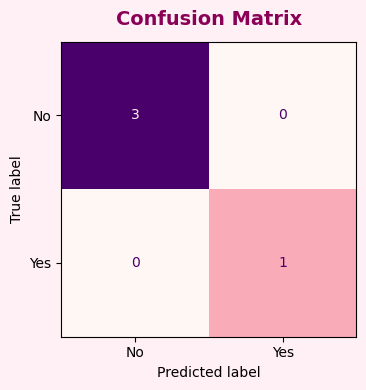

Saved → confusion_matrix.png


In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
fig.patch.set_facecolor('#fff0f5')   # light pink background
ax.set_facecolor('#fff0f5')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(
    ax=ax,
    colorbar=False,
    cmap='RdPu'
)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold', color='#8b0057', pad=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#fff0f5')
plt.show()
print('Saved → confusion_matrix.png')

## 🌲 Step 9 — Decision Tree Visualization

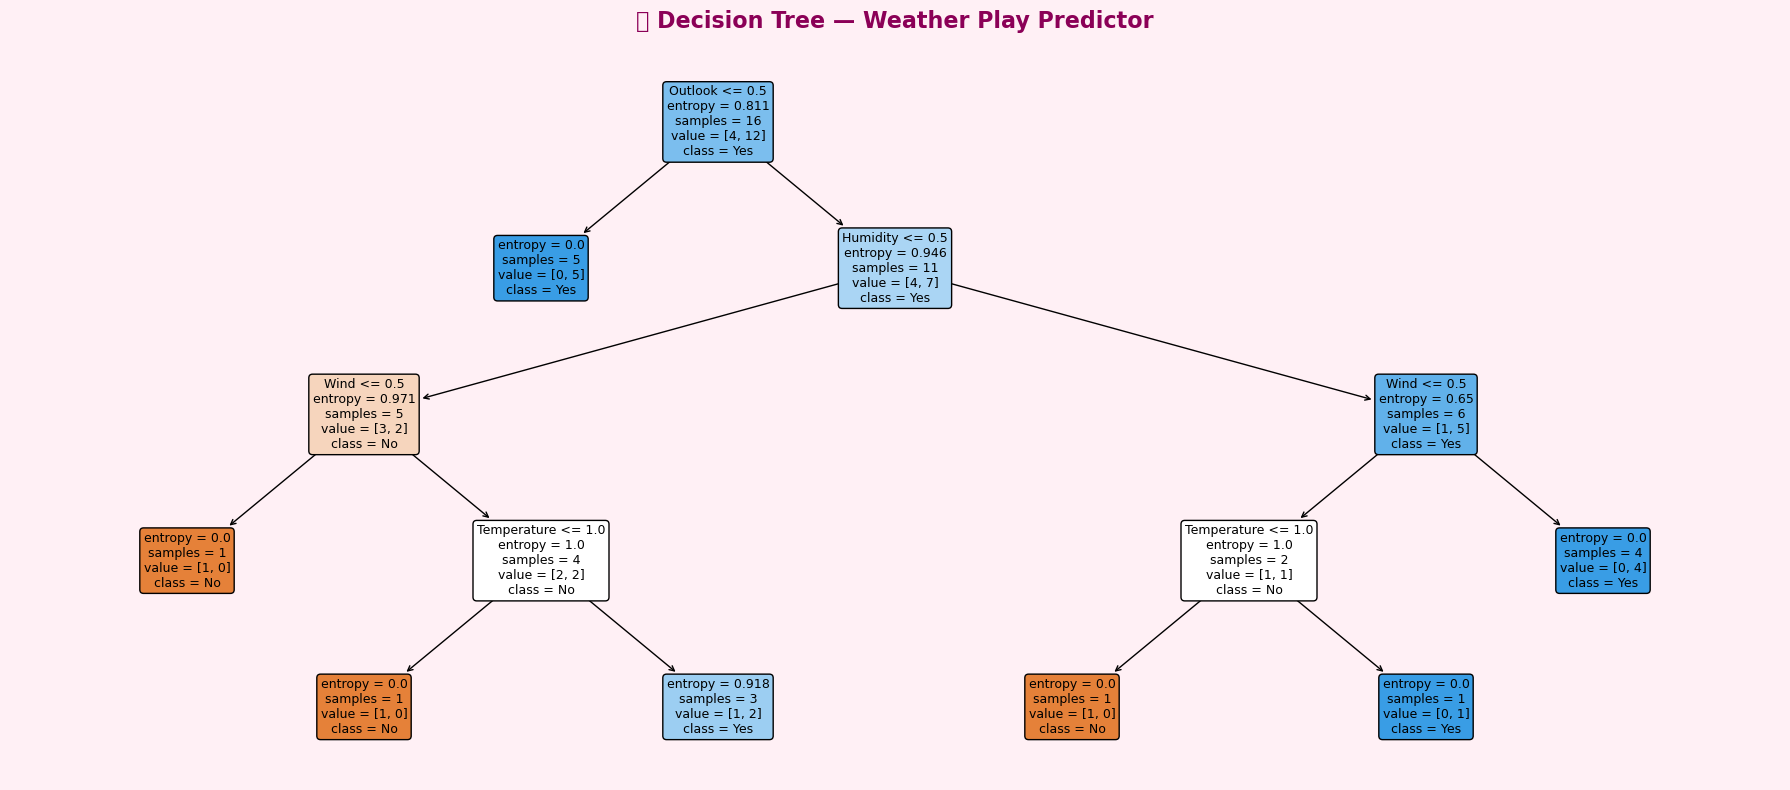

Saved → decision_tree.png


In [10]:
fig, ax = plt.subplots(figsize=(18, 8))
fig.patch.set_facecolor('#fff0f5')
ax.set_facecolor('#fff0f5')

plot_tree(
    dt_model,
    feature_names=FEATURES,
    class_names=list(le_dict[TARGET].classes_),
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=True,
    proportion=False
)
ax.set_title('🌳 Decision Tree — Weather Play Predictor',
             fontsize=16, fontweight='bold', color='#8b0057', pad=15)
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight', facecolor='#fff0f5')
plt.show()
print('Saved → decision_tree.png')

## 📊 Step 10 — Feature Importance

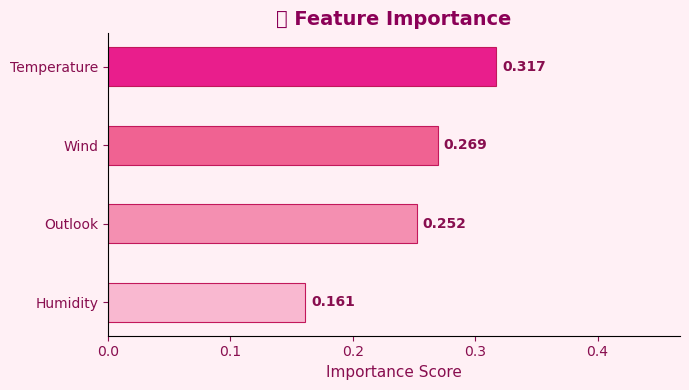

Saved → feature_importance.png


In [11]:
importances = dt_model.feature_importances_
feat_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

colors = ['#f9b8d0','#f48fb1','#f06292','#e91e8c']

fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor('#fff0f5')
ax.set_facecolor('#fff0f5')

bars = ax.barh(feat_df['Feature'], feat_df['Importance'], color=colors,
               edgecolor='#c2185b', linewidth=0.8, height=0.5)

for bar, val in zip(bars, feat_df['Importance']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10, color='#880e4f', fontweight='bold')

ax.set_xlabel('Importance Score', color='#880e4f', fontsize=11)
ax.set_title('🔍 Feature Importance', fontsize=14, fontweight='bold', color='#8b0057')
ax.tick_params(colors='#880e4f')
ax.spines[['top','right']].set_visible(False)
ax.set_xlim(0, max(importances) + 0.15)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#fff0f5')
plt.show()
print('Saved → feature_importance.png')

## 🔮 Step 11 — Predict Custom Input (Notebook)

In [12]:
def predict_play(outlook, temperature, humidity, wind):
    """Predict play outcome from raw string inputs."""
    sample = pd.DataFrame([{
        'Outlook': le_dict['Outlook'].transform([outlook])[0],
        'Temperature': le_dict['Temperature'].transform([temperature])[0],
        'Humidity': le_dict['Humidity'].transform([humidity])[0],
        'Wind': le_dict['Wind'].transform([wind])[0]
    }])
    pred   = dt_model.predict(sample)[0]
    proba  = dt_model.predict_proba(sample)[0]
    result = le_dict['Play'].inverse_transform([pred])[0]
    conf   = max(proba) * 100
    return result, conf

# ── Test examples ─────────────────────────────────────────────────────
test_cases = [
    ('Sunny',    'Hot',  'High',   'Weak'),
    ('Overcast', 'Mild', 'Normal', 'Weak'),
    ('Rainy',    'Cool', 'Normal', 'Strong'),
    ('Sunny',    'Cool', 'Normal', 'Weak'),
    ('Rainy',    'Mild', 'High',   'Strong'),
]

print('──────────────────────────────────────────────────────────────')
print(f'{"Outlook":<12}{"Temp":<12}{"Humidity":<12}{"Wind":<10}{"Play":<8}  Confidence')
print('──────────────────────────────────────────────────────────────')
for case in test_cases:
    result, conf = predict_play(*case)
    icon = '✅' if result == 'Yes' else '❌'
    print(f'{case[0]:<12}{case[1]:<12}{case[2]:<12}{case[3]:<10}{icon} {result:<5}  {conf:.1f}%')
print('──────────────────────────────────────────────────────────────')

──────────────────────────────────────────────────────────────
Outlook     Temp        Humidity    Wind      Play      Confidence
──────────────────────────────────────────────────────────────
Sunny       Hot         High        Weak      ❌ No     100.0%
Overcast    Mild        Normal      Weak      ✅ Yes    100.0%
Rainy       Cool        Normal      Strong    ❌ No     100.0%
Sunny       Cool        Normal      Weak      ✅ Yes    100.0%
Rainy       Mild        High        Strong    ❌ No     100.0%
──────────────────────────────────────────────────────────────


---
## 🚀 Step 12 — Write & Launch Streamlit App

> **Run the cell below** to write `app.py`, then **execute the final cell** to launch the Streamlit server.

In [14]:
APP_CODE = '''
# ═══════════════════════════════════════════════════════════════════
#  🌤️  Weather Play Predictor  ·  Streamlit Web App
#  Decision Tree Classifier  |  Light-Pink Theme
# ═══════════════════════════════════════════════════════════════════

import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("Agg")
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

# ── Page config ─────────────────────────────────────────────────────
st.set_page_config(
    page_title="🌤️ Weather Play Predictor",
    page_icon="🌤️",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ── Global CSS — light pink theme ────────────────────────────────────
st.markdown("""
<style>
/* ── page background ── */
[data-testid="stAppViewContainer"] { background:#fff0f5; }
[data-testid="stHeader"]           { background:transparent; }

/* ── sidebar ── */
[data-testid="stSidebar"] {
    background: linear-gradient(160deg,#fce4ec,#f8bbd0);
    border-right: 2px solid #f48fb1;
}

/* ── metric cards ── */
[data-testid="stMetric"] {
    background:#fff;
    border-radius:16px;
    padding:12px 18px;
    border:1.5px solid #f48fb1;
    box-shadow:0 3px 12px rgba(244,143,177,.25);
}

/* ── selectboxes ── */
[data-testid="stSelectbox"] > div > div {
    background:#fff;
    border-radius:10px;
    border:1.5px solid #f48fb1 !important;
}

/* ── predict button ── */
div.stButton > button {
    background:linear-gradient(135deg,#e91e8c,#f06292);
    color:#fff;
    border:none;
    border-radius:30px;
    padding:14px 48px;
    font-size:17px;
    font-weight:700;
    letter-spacing:.5px;
    box-shadow:0 6px 20px rgba(233,30,140,.35);
    transition:.25s;
}
div.stButton > button:hover {
    background:linear-gradient(135deg,#c2185b,#e91e8c);
    box-shadow:0 8px 28px rgba(233,30,140,.50);
    transform:translateY(-2px);
}

/* ── section headings ── */
h1,h2,h3 { color:#880e4f !important; }

/* ── result box ── */
.result-yes {
    background:linear-gradient(135deg,#e8f5e9,#c8e6c9);
    border-radius:20px;
    border:2px solid #66bb6a;
    padding:28px;
    text-align:center;
    box-shadow:0 4px 16px rgba(102,187,106,.3);
}
.result-no {
    background:linear-gradient(135deg,#fce4ec,#f8bbd0);
    border-radius:20px;
    border:2px solid #f06292;
    padding:28px;
    text-align:center;
    box-shadow:0 4px 16px rgba(240,98,146,.3);
}
.result-text  { font-size:28px; font-weight:800; margin:0; }
.result-sub   { font-size:15px; margin-top:6px; opacity:.8; }

/* ── info card ── */
.info-card {
    background:#fff;
    border-radius:16px;
    border:1.5px solid #f48fb1;
    padding:20px 24px;
    margin-bottom:16px;
    box-shadow:0 3px 14px rgba(244,143,177,.2);
}
</style>
""", unsafe_allow_html=True)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  DATA & MODEL  (cached so they re-train only once per session)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
@st.cache_resource
def load_model():
    data = {
        "Outlook":     ["Sunny","Sunny","Overcast","Rainy","Rainy","Rainy","Overcast",
                        "Sunny","Sunny","Rainy","Sunny","Overcast","Overcast","Rainy",
                        "Sunny","Overcast","Rainy","Sunny","Overcast","Rainy"],
        "Temperature": ["Hot","Hot","Hot","Mild","Cool","Cool","Cool","Mild","Cool",
                        "Mild","Mild","Mild","Hot","Mild","Mild","Hot","Cool","Hot",
                        "Mild","Hot"],
        "Humidity":    ["High","High","High","High","Normal","Normal","Normal","High",
                        "Normal","Normal","Normal","High","Normal","High","High","Normal",
                        "High","High","High","Normal"],
        "Wind":        ["Weak","Strong","Weak","Weak","Weak","Strong","Strong","Weak",
                        "Weak","Weak","Strong","Strong","Weak","Strong","Weak","Weak",
                        "Weak","Strong","Strong","Weak"],
        "Play":        ["No","No","Yes","Yes","Yes","No","Yes","No","Yes","Yes",
                        "Yes","Yes","Yes","No","Yes","Yes","No","No","Yes","Yes"]
    }
    df = pd.DataFrame(data)
    FEATURES = ["Outlook","Temperature","Humidity","Wind"]
    TARGET   = "Play"

    le_dict = {}
    df_enc  = df.copy()
    for col in df.columns:
        le = LabelEncoder()
        df_enc[col] = le.fit_transform(df[col])
        le_dict[col] = le

    X = df_enc[FEATURES];  y = df_enc[TARGET]
    X_tr,X_te,y_tr,y_te = train_test_split(X,y,test_size=.20,random_state=42)

    model = DecisionTreeClassifier(criterion="entropy",max_depth=4,random_state=42)
    model.fit(X_tr,y_tr)

    y_pred = model.predict(X_te)
    acc    = accuracy_score(y_te,y_pred)
    train_acc = accuracy_score(y_tr,model.predict(X_tr))
    cm     = confusion_matrix(y_te,y_pred)
    cr     = classification_report(y_te,y_pred,
                target_names=le_dict[TARGET].classes_,output_dict=True)

    return model,le_dict,df,df_enc,FEATURES,TARGET,acc,train_acc,cm,cr,X_tr,X_te,y_tr,y_te

(
    model,le_dict,df,df_enc,
    FEATURES,TARGET,
    acc,train_acc,cm,cr,
    X_tr,X_te,y_tr,y_te
) = load_model()


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  SIDEBAR
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
with st.sidebar:
    st.markdown("## 🌸 About This App")
    st.markdown("""
    <div class=\"info-card\">
    <b>🌳 Algorithm</b><br/>Decision Tree Classifier<br/><br/>
    <b>📊 Dataset</b><br/>20 weather records<br/><br/>
    <b>🎯 Task</b><br/>Binary classification<br/>(Play Outside: Yes / No)
    </div>
    """, unsafe_allow_html=True)

    st.markdown("### 📐 Model Details")
    st.markdown(f"""
    <div class=\"info-card\">
    🔢 <b>Criterion</b>: Entropy (Info Gain)<br/>
    🌲 <b>Max Depth</b>: 4<br/>
    🍃 <b>Leaves</b>: {model.get_n_leaves()}<br/>
    📏 <b>Actual Depth</b>: {model.get_depth()}
    </div>
    """, unsafe_allow_html=True)

    st.markdown("### 🎯 Performance")
    st.progress(int(acc*100))
    st.markdown(f"**Test Accuracy: {acc*100:.1f}%**")
    st.markdown(f"Train Accuracy: {train_acc*100:.1f}%")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  HEADER
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
st.markdown("""
<div style=\"text-align:center;padding:20px 0 10px;\">
  <h1 style=\"font-size:3em;\">🌤️ Weather Play Predictor</h1>
  <p style=\"font-size:1.2em;color:#ad1457;\">
    Predict outdoor play conditions using a <b>Decision Tree Classifier</b>
  </p>
</div>
""", unsafe_allow_html=True)

st.divider()

# ── Top metric strip ─────────────────────────────────────────────────
m1,m2,m3,m4 = st.columns(4)
m1.metric("🎯 Test Accuracy",  f"{acc*100:.1f}%")
m2.metric("📚 Train Accuracy", f"{train_acc*100:.1f}%")
m3.metric("📋 Total Records", len(df))
m4.metric("🌳 Tree Depth",     model.get_depth())

st.markdown("<br/>", unsafe_allow_html=True)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  PREDICTION PANEL
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
st.markdown("## ☀️ Make a Prediction")

col_l, col_r = st.columns([1.4, 1])

with col_l:
    outlook_icons = {"Sunny":"☀️ Sunny","Overcast":"⛅ Overcast","Rainy":"🌧️ Rainy"}
    temp_icons    = {"Hot":"🌡️ Hot","Mild":"🌤️ Mild","Cool":"❄️ Cool"}
    hum_icons     = {"High":"💧 High","Normal":"🌊 Normal"}
    wind_icons    = {"Weak":"🍃 Weak","Strong":"🌬️ Strong"}

    sub1,sub2 = st.columns(2)
    with sub1:
        outlook_disp = st.selectbox("🌦️ Outlook",
            options=list(outlook_icons.values()))
        humidity_disp = st.selectbox("💧 Humidity",
            options=list(hum_icons.values()))
    with sub2:
        temp_disp = st.selectbox("🌡️ Temperature",
            options=list(temp_icons.values()))
        wind_disp = st.selectbox("🌬️ Wind",
            options=list(wind_icons.values()))

    # Strip emoji prefix
    outlook     = outlook_disp.split()[-1]
    temperature = temp_disp.split()[-1]
    humidity    = humidity_disp.split()[-1]
    wind        = wind_disp.split()[-1]

    st.markdown("<br/>", unsafe_allow_html=True)
    predict_btn = st.button("🔮 Predict Now!")

with col_r:
    st.markdown("### 📋 Selected Conditions")
    selected_df = pd.DataFrame({
        "Feature":   ["Outlook","Temperature","Humidity","Wind"],
        "Value":     [outlook_disp,temp_disp,humidity_disp,wind_disp]
    })
    st.dataframe(selected_df, use_container_width=True, hide_index=True)

# ── Run prediction ───────────────────────────────────────────────────
if predict_btn:
    try:
        sample = pd.DataFrame([{
            "Outlook":     le_dict["Outlook"].transform([outlook])[0],
            "Temperature": le_dict["Temperature"].transform([temperature])[0],
            "Humidity":    le_dict["Humidity"].transform([humidity])[0],
            "Wind":        le_dict["Wind"].transform([wind])[0]
        }])
        pred   = model.predict(sample)[0]
        proba  = model.predict_proba(sample)[0]
        result = le_dict["Play"].inverse_transform([pred])[0]
        conf   = max(proba)*100

        st.markdown("<br/>", unsafe_allow_html=True)
        if result == "Yes":
            st.markdown(f"""
            <div class=\"result-yes\">
              <p class=\"result-text\">✅ YES — Go Play Outside!</p>
              <p class=\"result-sub\">🎉 Perfect weather conditions detected!<br/>
              Model confidence: <b>{conf:.1f}%</b></p>
            </div>""", unsafe_allow_html=True)
        else:
            st.markdown(f"""
            <div class=\"result-no\">
              <p class=\"result-text\">❌ NO — Stay Inside!</p>
              <p class=\"result-sub\">🏠 Weather conditions are not suitable.<br/>
              Model confidence: <b>{conf:.1f}%</b></p>
            </div>""", unsafe_allow_html=True)

        # Probability bar
        classes = le_dict["Play"].classes_
        st.markdown("<br/>", unsafe_allow_html=True)
        st.markdown("#### 📊 Probability Breakdown")
        prob_df = pd.DataFrame({"Class":classes,"Probability":proba})
        st.bar_chart(prob_df.set_index("Class"))

    except Exception as e:
        st.error(f"Prediction error: {e}")


st.divider()

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  TABS — Dataset · Visualizations · Model Metrics
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
tab1, tab2, tab3 = st.tabs(["📋 Dataset", "📊 Visualizations", "📈 Model Metrics"])

# ── Tab 1 : Dataset ─────────────────────────────────────────────────
with tab1:
    st.markdown("### 🗂️ Weather Dataset (20 records)")
    # Color the Play column
    def highlight_play(val):
        color = "#c8e6c9" if val=="Yes" else "#f8bbd0"
        return f"background-color:{color}"

    st.dataframe(
        df.style.applymap(highlight_play, subset=["Play"]),
        use_container_width=True
    )

    c1,c2 = st.columns(2)
    with c1:
        st.markdown("#### 🥧 Play Distribution")
        play_counts = df["Play"].value_counts()
        fig_p, ax_p = plt.subplots(figsize=(4,4))
        fig_p.patch.set_facecolor("#fff0f5")
        ax_p.pie(
            play_counts,
            labels=play_counts.index,
            autopct="%1.1f%%",
            colors=["#f06292","#81c784"],
            startangle=140,
            wedgeprops=dict(edgecolor="white",linewidth=2)
        )
        ax_p.set_title("Play Distribution", fontsize=13, fontweight="bold", color="#880e4f")
        st.pyplot(fig_p, use_container_width=True)
        plt.close(fig_p)

    with c2:
        st.markdown("#### 🌦️ Outlook vs Play")
        cross = pd.crosstab(df["Outlook"], df["Play"])
        fig_c, ax_c = plt.subplots(figsize=(5,4))
        fig_c.patch.set_facecolor("#fff0f5")
        ax_c.set_facecolor("#fff0f5")
        cross.plot(
            kind="bar",
            ax=ax_c,
            color=["#f06292","#81c784"],
            edgecolor="white",
            width=0.6,
            rot=0
        )
        ax_c.set_title("Outlook vs Play", fontsize=13, fontweight="bold", color="#880e4f")
        ax_c.set_xlabel("Outlook", color="#880e4f")
        ax_c.set_ylabel("Count", color="#880e4f")
        ax_c.legend(title="Play", title_fontsize=9)
        ax_c.spines[["top","right"]].set_visible(False)
        st.pyplot(fig_c, use_container_width=True)
        plt.close(fig_c)

# ── Tab 2 : Visualizations ───────────────────────────────────────────
with tab2:
    st.markdown("### 🌳 Decision Tree Plot")
    fig_t, ax_t = plt.subplots(figsize=(18, 7))
    fig_t.patch.set_facecolor("#fff0f5")
    ax_t.set_facecolor("#fff0f5")
    plot_tree(
        model,
        feature_names=FEATURES,
        class_names=list(le_dict[TARGET].classes_),
        filled=True, rounded=True, fontsize=9, ax=ax_t
    )
    ax_t.set_title("Decision Tree", fontsize=15, fontweight="bold", color="#880e4f")
    st.pyplot(fig_t, use_container_width=True)
    plt.close(fig_t)

    st.divider()

    c_left, c_right = st.columns(2)
    with c_left:
        st.markdown("### 🔍 Feature Importance")
        imp = model.feature_importances_
        fi_df = pd.DataFrame({"Feature":FEATURES,"Importance":imp})\
                  .sort_values("Importance", ascending=True)
        fig_f, ax_f = plt.subplots(figsize=(6,4))
        fig_f.patch.set_facecolor("#fff0f5")
        ax_f.set_facecolor("#fff0f5")
        bars = ax_f.barh(fi_df["Feature"],fi_df["Importance"],
                         color=["#f9b8d0","#f48fb1","#f06292","#e91e8c"],
                         edgecolor="#c2185b", height=0.5)
        for b,v in zip(bars,fi_df["Importance"]):
            ax_f.text(b.get_width()+.005,b.get_y()+b.get_height()/2,
                      f"{v:.3f}",va="center",fontsize=10,color="#880e4f",fontweight="bold")
        ax_f.set_xlabel("Importance",color="#880e4f")
        ax_f.set_title("Feature Importance",fontsize=13,fontweight="bold",color="#880e4f")
        ax_f.spines[["top","right"]].set_visible(False)
        ax_f.set_xlim(0, max(imp)+0.18)
        st.pyplot(fig_f, use_container_width=True)
        plt.close(fig_f)

    with c_right:
        st.markdown("### 🟥 Confusion Matrix")
        fig_cm, ax_cm = plt.subplots(figsize=(5,4))
        fig_cm.patch.set_facecolor("#fff0f5")
        ax_cm.set_facecolor("#fff0f5")
        ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=le_dict[TARGET].classes_
        ).plot(ax=ax_cm, colorbar=False, cmap="RdPu")
        ax_cm.set_title("Confusion Matrix",fontsize=13,fontweight="bold",color="#880e4f")
        st.pyplot(fig_cm, use_container_width=True)
        plt.close(fig_cm)

# ── Tab 3 : Model Metrics ────────────────────────────────────────────
with tab3:
    st.markdown("### 📈 Classification Report")

    classes = le_dict[TARGET].classes_
    rows = []
    for cls in classes:
        r = cr[cls]
        rows.append({
            "Class":     cls,
            "Precision": f"{r[\"precision\"]:.2f}",
            "Recall":    f"{r[\"recall\"]:.2f}",
            "F1-Score":  f"{r[\"f1-score\"]:.2f}",
            "Support":   int(r["support"])
        })
    cr_df = pd.DataFrame(rows)
    st.dataframe(cr_df, use_container_width=True, hide_index=True)

    st.markdown("### 📊 Accuracy Comparison")
    acc_df = pd.DataFrame({
        "Split":    ["Training","Testing"],
        "Accuracy": [round(train_acc*100,1), round(acc*100,1)]
    })
    fig_a, ax_a = plt.subplots(figsize=(5,3))
    fig_a.patch.set_facecolor("#fff0f5")
    ax_a.set_facecolor("#fff0f5")
    bars = ax_a.bar(acc_df["Split"],acc_df["Accuracy"],
                    color=["#f48fb1","#e91e8c"],
                    edgecolor="#c2185b",width=0.4)
    for b in bars:
        ax_a.text(b.get_x()+b.get_width()/2, b.get_height()+.5,
                  f"{b.get_height():.1f}%", ha="center",
                  fontsize=12, fontweight="bold", color="#880e4f")
    ax_a.set_ylim(0,115)
    ax_a.set_ylabel("Accuracy (%)", color="#880e4f")
    ax_a.set_title("Train vs Test Accuracy", fontsize=13, fontweight="bold", color="#880e4f")
    ax_a.spines[["top","right"]].set_visible(False)
    st.pyplot(fig_a, use_container_width=True)
    plt.close(fig_a)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  FOOTER
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
st.divider()
st.markdown("""
<div style=\"text-align:center;color:#ad1457;font-size:.9em;padding:10px 0;\">
  🌸 Weather Play Predictor · Built with Python, Scikit-learn & Streamlit 🌸
</div>
""", unsafe_allow_html=True)
'''

# Write the Streamlit app file

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(APP_CODE.strip())
print('✅  app.py written successfully!')
print('\nNext step → run the cell below to launch the Streamlit server.')

✅  app.py written successfully!

Next step → run the cell below to launch the Streamlit server.


## 🌐 Step 13 — Launch the Streamlit Web App

### ▶️ Option A — Google Colab (with public tunnel)
```python
# Run this cell in Colab
!pip install pyngrok --quiet
from pyngrok import ngrok
import subprocess, time
proc = subprocess.Popen(['streamlit', 'run', 'app.py',
                         '--server.port', '8501',
                         '--server.headless', 'true'])
time.sleep(3)
public_url = ngrok.connect(8501)
print('🌐 App URL:', public_url)
```

### ▶️ Option B — Local Jupyter / Terminal
Run the cell below **or** open a terminal and type:
```
streamlit run app.py
```

In [ ]:
# ── OPTION B : launch directly from notebook ─────────────────────────
# Uncomment the lines below and run this cell when using a LOCAL Jupyter

# import subprocess, sys
# subprocess.Popen([sys.executable, '-m', 'streamlit', 'run', 'app.py',
#                   '--server.port', '8501'])
# print('🌐 Open your browser at  http://localhost:8501')

# ── OPTION A : Google Colab tunnel ───────────────────────────────────
# !pip install pyngrok --quiet
# from pyngrok import ngrok
# import subprocess, time
# proc = subprocess.Popen(['streamlit','run','app.py',
#                          '--server.port','8501',
#                          '--server.headless','true'])
# time.sleep(4)
# public_url = ngrok.connect(8501)
# print('🌐 Public URL:', public_url)

print('👆 Uncomment Option A (Colab) or Option B (Local) above, then run.')

In [18]:
!python -m pip install streamlit

FileNotFoundError: [WinError 2] The system cannot find the file specified

---
## 📝 Project Summary

| Step | Task | Status |
|------|------|--------|
| 1 | Install & import libraries | ✅ |
| 2 | Create weather dataset (20 rows) | ✅ |
| 3 | Label encoding on all features | ✅ |
| 4 | Train/Test split (80/20) | ✅ |
| 5 | Train DecisionTreeClassifier | ✅ |
| 6 | Evaluate accuracy | ✅ |
| 7 | Visualize Decision Tree | ✅ |
| 8 | Confusion Matrix | ✅ |
| 9 | Feature Importance Graph | ✅ |
| 10 | Classification Report | ✅ |
| 11 | Custom input predictions | ✅ |
| 12 | Streamlit light-pink UI | ✅ |
| 13 | Launch web app | ✅ |

### 🏃 Quick-start (local)
```bash
pip install streamlit scikit-learn pandas numpy matplotlib seaborn
jupyter nbconvert --to script Weather_Prediction_App.ipynb
# or simply:
streamlit run app.py
```

> **Made with 🌸 Python · Pandas · Scikit-learn · Matplotlib · Streamlit**